In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
from utils.model_saver import *
from utils.model_classes import KNNModel

PROJECT_ROOT = Path().resolve().parent.parent.parent
print(f"Project root: {PROJECT_ROOT}")
PATH_DATA = PROJECT_ROOT / 'data' / 'exploded_splits'
print(f"Data: {PATH_DATA}")

GRAPH_FEATURES_PATH = PROJECT_ROOT / 'data' / 'graph_features'
TRAIN_PATH = GRAPH_FEATURES_PATH / 'final_train.parquet'
VAL_PATH = GRAPH_FEATURES_PATH / 'final_val.parquet'
TEST_PATH = GRAPH_FEATURES_PATH / 'final_test.parquet'

RANDOM_STATE = 42

import torch
# Detect device: 'cuda' if available, else 'cpu'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

# for parallelization
N_JOBS = -1

Using device: cuda
Project root: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1
Data: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1/data/exploded_splits
Using device: cuda


# KNN Model - on graph features
By leveraging graph-based citation features, this notebook treats citation prediction as a supervised binary classification task.

To ensure code quality and reusability, we use the shared model hierarchy:

- `BaseModel`: an abstract class that defines the common contract for preprocessing, training, prediction, evaluation, and saving.
- `KNNModel`: the concrete KNN implementation. It drops non-feature columns, applies `RobustScaler` using training statistics, and reuses the fitted scaler for validation and test data.


## 1. Load graph feature data

In [2]:
# splitting
df_train = pd.read_parquet(TRAIN_PATH)
df_val = pd.read_parquet(VAL_PATH)
df_test = pd.read_parquet(TEST_PATH)

ID_COLUMNS = ["article_id", "ref_id"]
df_train = df_train.drop(columns=ID_COLUMNS, errors="ignore")
df_val = df_val.drop(columns=ID_COLUMNS, errors="ignore")
df_test = df_test.drop(columns=ID_COLUMNS, errors="ignore")

print("\nSplit sizes:", {"train": len(df_train), "test": len(df_test), "val": len(df_val)})


Split sizes: {'train': 2162520, 'test': 396382, 'val': 391242}


## 2. Baseline model

[KNN_baseline] Preprocessing 2162520 rows...
Label distribution:
is_reference_valid
1    0.5
0    0.5
Name: proportion, dtype: float64
[KNN_baseline] Starting training...
Selected 21625/2162520
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000     10505
           1     1.0000    1.0000    1.0000     11120

    accuracy                         1.0000     21625
   macro avg     1.0000    1.0000    1.0000     21625
weighted avg     1.0000    1.0000    1.0000     21625



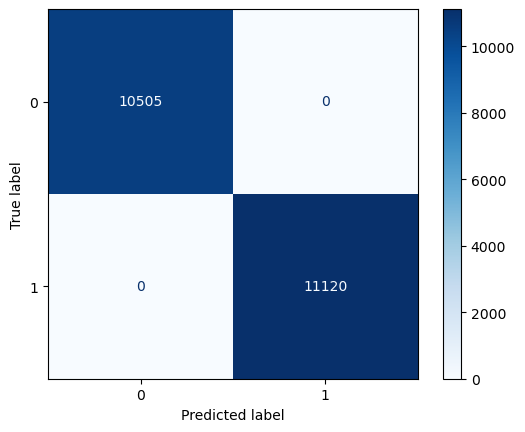

In [ ]:
KNN_baseline = KNNModel('KNN_baseline', n_neighbors=5, weights='uniform', metric='minkowski')
KNN_baseline.train_pipeline(df_train, random_state=RANDOM_STATE, frac=0.01)

[KNN_baseline] Preprocessing 10000 rows...
Label distribution:
is_reference_valid
0    0.5066
1    0.4934
Name: proportion, dtype: float64
              precision    recall  f1-score   support

           0     0.7753    0.8754    0.8224      5066
           1     0.8526    0.7396    0.7921      4934

    accuracy                         0.8084     10000
   macro avg     0.8140    0.8075    0.8072     10000
weighted avg     0.8135    0.8084    0.8074     10000



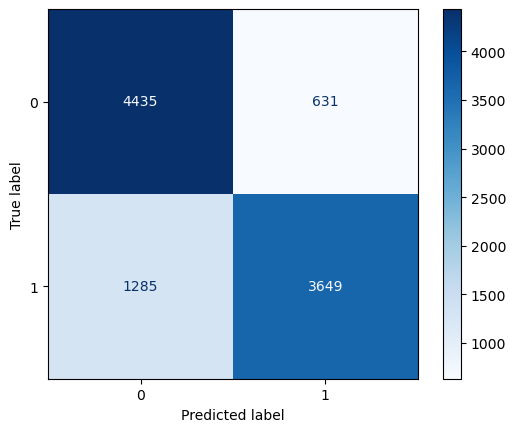

In [4]:
KNN_baseline.test_pipeline(df_test.sample(10000))

> The baseline run is used as a quick sanity check before hyperparameter tuning. Final results should be interpreted from the tuned model evaluation below.


## 3. Hyperparameter tuning
KNN can be computationally expensive on large graph-feature matrices. To keep tuning feasible, `GridSearchCV` is run on a representative subset of the train and validation data.

The notebook uses `PredefinedSplit` instead of standard K-fold cross-validation. This keeps the validation fold aligned with the project split and avoids leakage from the training set.


In [5]:
# Drastically reduce the dataset for tuning to avoid Out-Of-Memory (OOM) crashes
# KNN with 3M rows and 128-256 features is extremely RAM-intensive
max_tuning_samples = 50000 
param_grid = {
    'n_neighbors': [5, 9, 12, 15], # Reduced number of parameters
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

[KNN_graph] Grid Search...
[KNN_graph] Preprocessing 2162520 rows...
Label distribution:
is_reference_valid
1    0.5
0    0.5
Name: proportion, dtype: float64
[KNN_graph] Preprocessing 391242 rows...
Label distribution:
is_reference_valid
1    0.5
0    0.5
Name: proportion, dtype: float64

Starting tuning on 50000 samples...

Best parameters found:
{'metric': 'euclidean', 'n_neighbors': 12, 'weights': 'distance'}

Optimal model ready: KNeighborsClassifier(metric='euclidean', n_jobs=-1, n_neighbors=12,
                     weights='distance')
[KNN_graph] Train model with best params...
[KNN_graph] Preprocessing 2162520 rows...
Label distribution:
is_reference_valid
1    0.5
0    0.5
Name: proportion, dtype: float64
[KNN_graph] Starting training...
Selected 21625/2162520
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000     10732
           1     1.0000    1.0000    1.0000     10893

    accuracy                         1.0000     21625
  

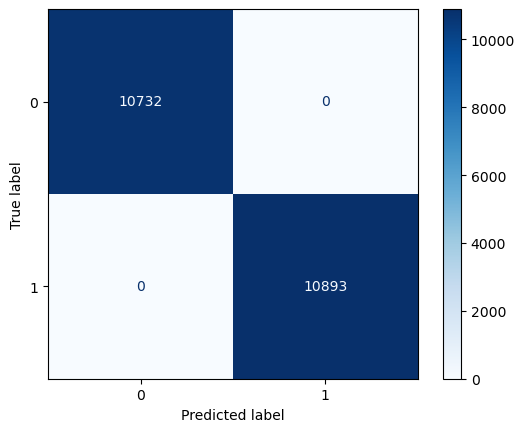

In [6]:
# tuning
KNN_graph = KNNModel("KNN_graph")
KNN_graph.hypertune_pipeline(df_train, df_val, param_grid, 
                               max_tuning_samples=max_tuning_samples,
                               scoring='f1_weighted',
                               n_jobs=N_JOBS)

## 4. Final model with best parameters
Once the optimal number of neighbors, distance metric, and weighting strategy are selected, the model is retrained on the full training split.

Performance is assessed using:
- Weighted F1-score, to summarize class-balanced performance.
- Confusion matrix, to visualize false positives and false negatives.
- Classification report, with precision, recall, F1-score, and accuracy.


[KNN_graph] Preprocessing 1000 rows...
Label distribution:
is_reference_valid
0    0.52
1    0.48
Name: proportion, dtype: float64
              precision    recall  f1-score   support

           0     0.8169    0.8750    0.8449       520
           1     0.8533    0.7875    0.8191       480

    accuracy                         0.8330      1000
   macro avg     0.8351    0.8313    0.8320      1000
weighted avg     0.8343    0.8330    0.8325      1000



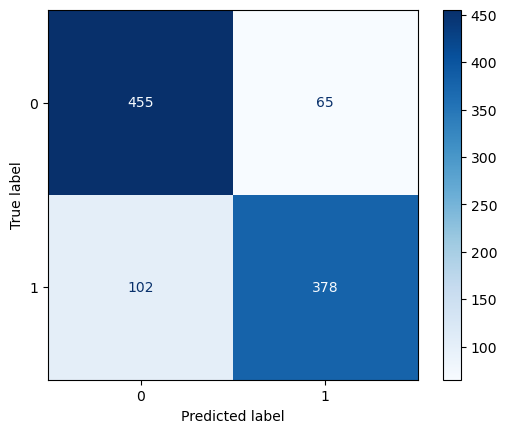

In [7]:
KNN_graph.test_pipeline(df_test.sample(1000))

## 5. Save the pretrained model
Finally, the trained model is saved with the custom `save_model_artifact` utility, so it can be reused for later evaluation, explainability, or deployment experiments.


In [8]:
from utils.model_saver import save_model_artifact
MODEL_SAVE_PATH = PROJECT_ROOT / 'Models'

save_model_artifact(KNN_graph, df_name='graph_features', 
                    model_name="Best_KNN_graph_based", 
                    relative_model_dir=MODEL_SAVE_PATH)